# 7.8 Himmelblau 函数优化实战

Himmelblau 函数是用来测试优化算法的常用样例函数之一，它包含了两个自变量𝑥和
𝑦，数学表达式是：
𝑓(𝑥, 𝑦) = (𝑥
2 + 𝑦 − 11)
2 + (𝑥 + 𝑦
2 − 7)
2
首先我们通过如下代码实现 Himmelblau 函数的表达式：

In [2]:
import numpy as np


def himmelblau(x):
    # himmelblau 函数实现，传入参数 x 为 2 个元素的 List
    return (x[0] ** 2 + x[1] - 11) ** 2 + (x[0] + x[1] ** 2 - 7) ** 2


x = np.linspace(-6, 6, 120)
y = np.linspace(-6, 6, 120)
print('x,y range:', x.shape, y.shape)
# 生成 x-y 平面采样网格点，方便可视化
X, Y = np.meshgrid(x, y)
print('X, Y maps:', X.shape, Y.shape)
Z = himmelblau([X, Y])  # 计算网格点上的函数值

x,y range: (120,) (120,)
X, Y maps: (120, 120) (120, 120)


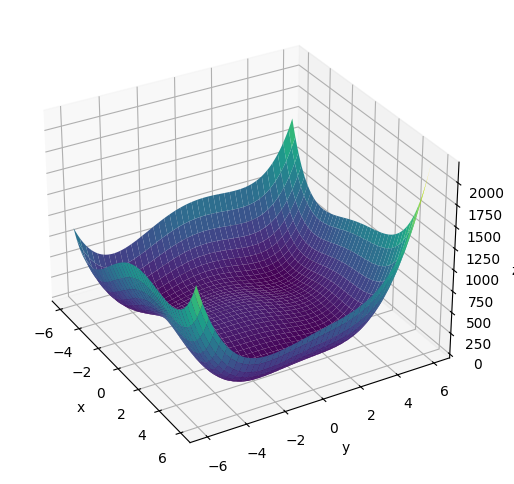

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 6))
ax.plot_surface(X, Y, Z, cmap='viridis', shade=True)  # 绘制3D曲面
# 设置观察角度
ax.view_init(elev=30, azim=-30)

# 坐标轴标签
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')  # 也可以加上 z 轴标签

plt.show()

图 7.12 为 Himmelblau 函数的等高线图，大致可以看出，它共有 4 个局部极小值点，
并且局部极小值都是 0，所以这 4 个局部极小值也是全局最小值。我们可以通过解析的方
法计算出局部极小值的精确坐标，它们分别是：
(3,2), (−2 805, 3 131), (−3 779, −3 283), (3 584, −1 848)
在已经知晓极值解析解的情况下，我们现在利用梯度下降算法来优化 Himmelblau 函数
的极小值数值解。

利用 TensorFlow 自动求导来求出函数在𝑥和𝑦的偏导数，并循环迭代更新𝑥和𝑦值，代码
如下：

In [7]:
import tensorflow as tf


# 参数的初始化值对优化的影响不容忽视，可以通过尝试不同的初始化值，
# 检验函数优化的极小值情况
# [1., 0.], [-4, 0.], [4, 0.]
x = tf.constant([4., 0.])

for step in range(200):
    with tf.GradientTape() as tape:  # 梯度跟踪
        tape.watch([x])  # 加入梯度跟踪列表
        y = himmelblau(x)  # 向前传播
    # 反向传播
    grads = tape.gradient(y, [x])[0]
    # 更新参数，0.01为学习率
    x -= 0.01 * grads
    # 打印优化的极小值
    if step % 20 == 0:
        print('step {}: x = {}, f(x) = {}'.format(step, x.numpy(), y.numpy()))

step 0: x = [ 3.26       -0.09999999], f(x) = 34.0
step 20: x = [ 3.54679   -1.4388103], f(x) = 2.747403860092163
step 40: x = [ 3.5843565 -1.8473401], f(x) = 1.7569736883160658e-05
step 60: x = [ 3.5844283 -1.8481257], f(x) = 2.3646862246096134e-11
step 80: x = [ 3.5844283 -1.8481264], f(x) = 2.2737367544323206e-13
step 100: x = [ 3.5844283 -1.8481264], f(x) = 2.2737367544323206e-13
step 120: x = [ 3.5844283 -1.8481264], f(x) = 2.2737367544323206e-13
step 140: x = [ 3.5844283 -1.8481264], f(x) = 2.2737367544323206e-13
step 160: x = [ 3.5844283 -1.8481264], f(x) = 2.2737367544323206e-13
step 180: x = [ 3.5844283 -1.8481264], f(x) = 2.2737367544323206e-13


经过 200 次迭代更新后，程序可以找到一个极小值解，此时函数值接近于 0。找到的数值
解为：
step 199: x = [ 3.584428 -1.8481264], f(x) = 1.1368684856363775e-12
这与解析解之一(3 584, −1 848)几乎一样。
实际上，通过改变网络参数的初始化状态，程序可以得到多种极小值数值解。参数的
初始化状态是可能影响梯度下降算法的搜索轨迹的，甚至有可能搜索出完全不同的数值
解，如表 7.1 所示。这个例子就比较好地解释了不同的初始状态对梯度下降算法的影响。